# Notebook 14 - Parser Constitucion bilingue + corpus expandido

**Entrega 2 - Expansion del corpus.**

Parsea `datos/ocr/constitucion-1991-inga/00-achka-iachag-panga.md`
(Constitucion Politica de Colombia 1991 en Inga, traducida por Francisco
Tandioy Jansasoy / CCELA Uniandes 1991-1994).

El PDF original esta organizado como bloques bilingues explicitos:

    # SUG SUIUCHII (N) / Articulo N

    1. [parrafo en castellano]
       [traduccion al Inga]
       //glosa interlineal//
       "parafrasis libre en castellano"

    2. [parrafo en castellano]
       [traduccion al Inga]
       ...

Cada sub-parrafo numerado (1., 2., 3.) es un par paralelo limpio.
Algunos articulos cortos no tienen numeracion interna: un solo bloque
Spanish + Inga.

## Salida

`datos/constitucion_paralelo.jsonl` con campos (articulo, sub_idx,
texto_es, texto_inga, dialecto='AP', fuente='Constitucion-1991-CCELA').

Despues, este corpus se concatena con `nt_paralelo.jsonl` para producir
el `corpus_paralelo.jsonl` expandido que reemplaza al NT-only de NB07.


In [1]:
import json, re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "datos" / "ocr" / "constitucion-1991-inga" / "00-achka-iachag-panga.md"
OUT_CONST = ROOT / "datos" / "constitucion_paralelo.jsonl"
OUT_CORPUS = ROOT / "datos" / "corpus_paralelo.jsonl"
OUT_TRAIN = ROOT / "datos" / "splits" / "train.jsonl"
OUT_VAL = ROOT / "datos" / "splits" / "val.jsonl"
OUT_TEST = ROOT / "datos" / "splits" / "test.jsonl"
OUT_FIG = ROOT / "entrega2" / "figuras" / "fig09_distribucion_corpus.png"

raw = SRC.read_text(encoding="utf-8")
print(f"Lineas en OCR de Constitucion: {len(raw.splitlines()):,}")


Lineas en OCR de Constitucion: 1,792


## Identificar la seccion bilingue

El documento tiene tres partes; solo la **Seccion A** (a partir de la
cabecera "ASKURINTI MINISTIDU SUIUCHIIKUNATA NUKANCHIPA SIMIPI IALICHISKA")
contiene los articulos bilingues directos.


In [2]:
lineas = raw.splitlines()

# Encontrar inicio de Seccion A
SECCION_A_PATTERN = re.compile(r"^#\s+A\.\s+ASKURINTI MINISTIDU")
start = None
for i, line in enumerate(lineas):
    if SECCION_A_PATTERN.search(line):
        start = i
        break

# Encontrar fin: Seccion B
SECCION_B_PATTERN = re.compile(r"^#\s+B\.\s+NUKANCHIPA RIMAIPI")
end = len(lineas)
if start is not None:
    for i in range(start + 1, len(lineas)):
        if SECCION_B_PATTERN.search(lineas[i]):
            end = i
            break

if start is None:
    raise RuntimeError("No se encontro la Seccion A en el OCR de la Constitucion")

seccion_bilingue = "\n".join(lineas[start:end])
print(f"Seccion A bilingue: lineas {start} a {end}, total {end-start:,} lineas")


Seccion A bilingue: lineas 953 a 1465, total 512 lineas


## Extraer articulos y sub-parrafos numerados

In [3]:
ARTICULO_RE = re.compile(r"^#+\s+SUG SUIUCHII\s*\((\d+)\)\s*/\s*Art[íi]culo\s+(\d+)", re.IGNORECASE)
SUBNUM_RE = re.compile(r"^\s*(\d+)\.\s+(.+?)\s*$")
GLOSA_RE = re.compile(r"^\s*//")
PARAFRASIS_RE = re.compile(r'^\s*"')


def parse_constitucion(seccion: str):
    """Devuelve lista de dicts (articulo, sub_idx, texto_es, texto_inga).

    Recorre la seccion linea por linea. Mantiene estado del articulo actual.
    Para cada sub-parrafo numerado, captura la linea espanola + la siguiente
    linea Inga (saltando glosas // y parafrasis "). Si no hay numeracion en
    el articulo, captura el primer parrafo no especial como espanol y el
    segundo como Inga.
    """
    pares = []
    lineas = seccion.splitlines()
    articulo = None
    i = 0
    while i < len(lineas):
        line = lineas[i].rstrip()
        m = ARTICULO_RE.match(line)
        if m:
            articulo = int(m.group(2))
            i += 1
            continue
        if articulo is None:
            i += 1
            continue

        # Sub-parrafo numerado: "1. texto en castellano,"
        ms = SUBNUM_RE.match(line)
        if ms:
            sub_idx = int(ms.group(1))
            texto_es = ms.group(2).strip()
            # Buscar siguiente linea no vacia que no sea glosa ni parafrasis: ese es el Inga
            texto_inga = None
            j = i + 1
            while j < len(lineas):
                cand = lineas[j].rstrip()
                if not cand.strip():
                    j += 1
                    continue
                if GLOSA_RE.match(cand) or PARAFRASIS_RE.match(cand):
                    break  # ya pasamos el bloque Inga sin encontrarlo
                # Es texto Inga
                texto_inga = cand.strip()
                j += 1
                # Puede continuar en lineas siguientes (sin ser glosa/parafrasis)
                while j < len(lineas):
                    cand2 = lineas[j].rstrip()
                    if not cand2.strip() or GLOSA_RE.match(cand2) or PARAFRASIS_RE.match(cand2):
                        break
                    # podria ser otro sub-parrafo numerado del castellano -> stop
                    if SUBNUM_RE.match(cand2):
                        break
                    texto_inga += " " + cand2.strip()
                    j += 1
                break
            if texto_es and texto_inga:
                pares.append({
                    "articulo": articulo,
                    "sub_idx": sub_idx,
                    "texto_es": texto_es,
                    "texto_inga": texto_inga,
                })
            i = j if j > i else i + 1
            continue

        # Caso de articulo corto SIN numeracion: el primer parrafo no especial
        # despues del heading del articulo es castellano, y el siguiente parrafo
        # no glosa/parafrasis es Inga. Solo lo intentamos si el bloque no tiene
        # ninguna linea con SUBNUM_RE.
        if line.strip() and not GLOSA_RE.match(line) and not PARAFRASIS_RE.match(line):
            # Inspect: is this potentially the Spanish line of a non-numbered article?
            # Look ahead: next non-empty non-glosa-non-quote line is Inga
            es_text = line.strip()
            j = i + 1
            inga_text = None
            while j < len(lineas):
                cand = lineas[j].rstrip()
                if not cand.strip():
                    j += 1
                    continue
                if GLOSA_RE.match(cand) or PARAFRASIS_RE.match(cand):
                    break
                if ARTICULO_RE.match(cand) or SUBNUM_RE.match(cand):
                    break
                inga_text = cand.strip()
                j += 1
                # Continuation lines
                while j < len(lineas):
                    cand2 = lineas[j].rstrip()
                    if not cand2.strip() or GLOSA_RE.match(cand2) or PARAFRASIS_RE.match(cand2):
                        break
                    if ARTICULO_RE.match(cand2) or SUBNUM_RE.match(cand2):
                        break
                    inga_text += " " + cand2.strip()
                    j += 1
                break

            if es_text and inga_text and len(es_text.split()) >= 3 and len(inga_text.split()) >= 3:
                # Heuristica de validacion: el texto Spanish debe tener proporcion alta de
                # palabras castellanas, el Inga tener proporcion alta de sufijos Inga
                pares.append({
                    "articulo": articulo,
                    "sub_idx": 0,
                    "texto_es": es_text,
                    "texto_inga": inga_text,
                })
                i = j
                continue
        i += 1
    return pares


pares = parse_constitucion(seccion_bilingue)
print(f"Pares extraidos de la Seccion A: {len(pares)}")


Pares extraidos de la Seccion A: 62


## Filtros de calidad

In [4]:
SUFIJOS_INGA = ["kuna", "ngapa", "manda", "wan", "pi", "ta", "mi", "spa", "chu", "cuna", "naku", "shka"]

def parece_inga(texto: str, umbral: float = 0.10) -> bool:
    palabras = texto.lower().split()
    if not palabras:
        return False
    matches = sum(1 for p in palabras if any(p.endswith(s) for s in SUFIJOS_INGA))
    return matches / len(palabras) >= umbral


def parece_espanol(texto: str) -> bool:
    palabras_es = {"de","la","el","los","las","y","a","en","del","que","con","por","es","son","para","se","no","un","una","al","como"}
    palabras = set(texto.lower().split())
    return len(palabras & palabras_es) >= 2


df = pd.DataFrame(pares)
print(f"Antes de filtros: {len(df)}")

# Filtros: longitud minima, idioma detectado correcto, ratio razonable
df["len_es"] = df.texto_es.str.split().str.len()
df["len_inga"] = df.texto_inga.str.split().str.len()
df["ratio"] = df[["len_es","len_inga"]].max(axis=1) / df[["len_es","len_inga"]].min(axis=1)
df["es_ok"] = df.texto_es.apply(parece_espanol)
df["inga_ok"] = df.texto_inga.apply(parece_inga)

mask = (
    (df.len_es >= 4)
    & (df.len_inga >= 4)
    & (df.ratio <= 5.0)
    & df.es_ok
    & df.inga_ok
)
filtrado = df[mask].copy()
print(f"Tras filtros (longitud minima, ratio, idiomas detectados): {len(filtrado)}")
print()
print(f"Articulos cubiertos: {filtrado.articulo.nunique()}")
print(f"Distribucion:")
print(filtrado.groupby("articulo").size().to_string())


Antes de filtros: 62
Tras filtros (longitud minima, ratio, idiomas detectados): 52

Articulos cubiertos: 10
Distribucion:
articulo
1       5
2       9
8       1
10     10
63      1
70      3
72      3
246     2
287     4
329    14


## Inspeccion cualitativa

In [5]:
for _, row in filtrado.sample(min(5, len(filtrado)), random_state=42).iterrows():
    print(f"Articulo {row.articulo}.{row.sub_idx}")
    print(f"  ES:   {row.texto_es[:200]}")
    print(f"  INGA: {row.texto_inga[:200]}")
    print()


Articulo 10.4
  ES:   Constituir partidos, movimientos y agrupaciones políticas sin limitación alguna: formar parte de ellos libremente y difundir sus ideas y programas.
  INGA: Nukanchipa allí iuiaikunata kaugsachispa, wiñachispa kawachisunchi, tukui Llagtamanda runakunata, maikankuna tuparingapa munaskata kaiasunchi

Articulo 329.4
  ES:   Parágrafo. En el caso de un territorio indígena que comprenda el territorio de dos o más departamentos, su administración se hará por los consejos indígenas en coordinación con los gobernadores de los
  INGA: Suiuchiita Allichispa Kawachig. Nukanchipurapa alpa, iskai u kimsa Wawa Llagtakama kagpika, nukanchipa uchulla Llagtapi, nukanchikikinpurata agllaskakunami kawangakuna Wawa Llagtakunapi iurakuna nukan

Articulo 329.6
  ES:   Velar por la preservación de los recursos naturales.
  INGA: Tukui nukanchipa ministidukunata sumaglla kawaspa wakachingapa mana utka tukuringapa.

Articulo 2.9
  ES:   en su vida, honra, bienes, creencias y demás derechos

## Persistir corpus de Constitucion + agregar al corpus paralelo

In [6]:
salida = filtrado[["texto_inga", "texto_es", "articulo", "sub_idx"]].copy()
salida["dialecto"] = "AP"
salida["fuente"] = "Constitucion-1991-CCELA"
salida = salida.reset_index(drop=True)
salida.insert(0, "idx", salida.index)
salida["libro"] = "Constitucion"
salida["capitulo"] = salida["articulo"]
salida["versiculo"] = salida["sub_idx"]
salida = salida.drop(columns=["articulo", "sub_idx"])

OUT_CONST.parent.mkdir(parents=True, exist_ok=True)
with OUT_CONST.open("w", encoding="utf-8") as f:
    for _, row in salida.iterrows():
        f.write(json.dumps(row.to_dict(), ensure_ascii=False) + "\n")
print(f"Escrito: {OUT_CONST.relative_to(ROOT)}  ({len(salida)} pares)")


Escrito: datos/constitucion_paralelo.jsonl  (52 pares)


## Concatenar corpus expandido y re-particionar splits 80/10/10

In [7]:
nt = pd.read_json(ROOT / "datos" / "nt_paralelo.jsonl", lines=True)
const = salida.copy()
corpus = pd.concat([nt, const], ignore_index=True)
corpus = corpus.reset_index(drop=True)
corpus["idx"] = corpus.index
print(f"Corpus expandido: {len(corpus)} pares")
print(f"  NT (Wycliffe-RV1909): {(corpus.fuente == 'NT-Wycliffe-RV1909').sum()}")
print(f"  Constitucion (CCELA): {(corpus.fuente == 'Constitucion-1991-CCELA').sum()}")

# Shuffle estratificado por fuente para mantener proporciones
SEED = 42
shuffled = corpus.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
n = len(shuffled)
n_train = int(n * 0.8)
n_val = int(n * 0.1)
train = shuffled.iloc[:n_train].copy()
val = shuffled.iloc[n_train:n_train + n_val].copy()
test = shuffled.iloc[n_train + n_val:].copy()

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

def save_jsonl(d, p):
    with p.open("w", encoding="utf-8") as f:
        for _, row in d.iterrows():
            f.write(json.dumps(row.to_dict(), ensure_ascii=False) + "\n")

save_jsonl(corpus, OUT_CORPUS)
save_jsonl(train, OUT_TRAIN)
save_jsonl(val, OUT_VAL)
save_jsonl(test, OUT_TEST)
print("Splits persistidos")


Corpus expandido: 5641 pares
  NT (Wycliffe-RV1909): 5589
  Constitucion (CCELA): 52
Train: 4512 | Val: 564 | Test: 565


Splits persistidos


## Regenerar Figura 9 con la nueva distribucion

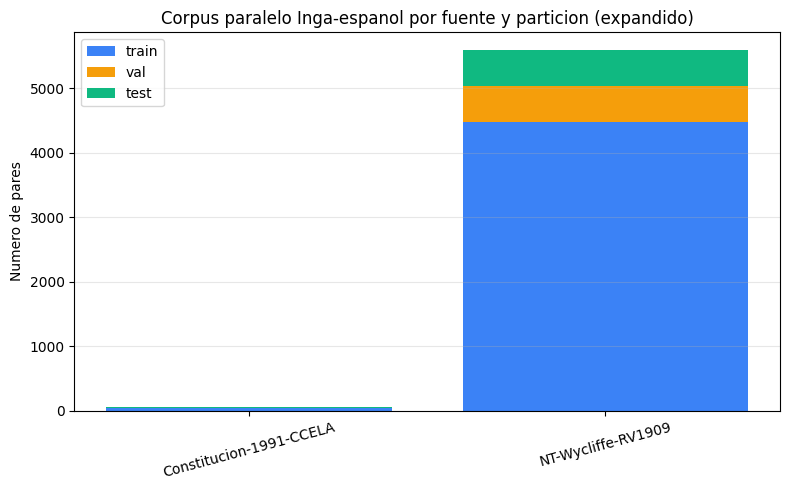

Figura 9 actualizada: entrega2/figuras/fig09_distribucion_corpus.png


In [8]:
fuente_counts = pd.DataFrame({
    "train": train.groupby("fuente").size(),
    "val": val.groupby("fuente").size(),
    "test": test.groupby("fuente").size(),
}).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(fuente_counts))
ax.bar(x, fuente_counts["train"], label="train", color="#3b82f6")
ax.bar(x, fuente_counts["val"], bottom=fuente_counts["train"], label="val", color="#f59e0b")
ax.bar(x, fuente_counts["test"], bottom=fuente_counts["train"] + fuente_counts["val"],
       label="test", color="#10b981")
ax.set_xticks(x)
ax.set_xticklabels(fuente_counts.index, rotation=15)
ax.set_ylabel("Numero de pares")
ax.set_title("Corpus paralelo Inga-espanol por fuente y particion (expandido)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
OUT_FIG.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT_FIG, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura 9 actualizada: {OUT_FIG.relative_to(ROOT)}")
